# 계절적 자기회귀누적이동평균(seasonal autoregressive integrated moving average, SARIMA) 모델

- 계절적 매개변수를 추가하여 ARIMA(p, d, q) 모델을 확장한 것

- SARIMA(p, d, q)(P, D, Q)m에는 네 가지 새로운 매개변수가 존재
    - (P, D, Q)는 ARIMA 모델과 동일한 의미를 갖지만 계절에 따라 달라짐
    - 이러한 매개변수의 의미와 최종 모델에 어떤 영향을 미치는지 이해하려면 m을 정의해야 함

- m은 빈도를 나타냄. 시계열의 맥락에서 빈도는 주기 당 관측 횟수로 정의
    - 매년, 분기, 월, 주 단위로 기록된 데이터의 경우 주기의 길이는 일반적으로 1년으로 간주
        - 매년 기록된 경우, 1년에 관찰이 한 번만 있으므로 m = 1
        - 분기 데이터는 m = 4
        - 월별은 m = 12
        - 주간은 m = 52
 
    - 일별 또는 그 하위 단계로 수집되는 경우 빈도를 해석하는 방법은 여러 가지
        - 예) 일별 데이터가 주간 계절성을 가지는 경우 m = 7
        - 연간 계절성을 가지는 경우 m = 365

    - 예) m = 12인 경우, P = 2이면 m의 배수인 지연에 대해 두 개의 과거 시계열값을 포함한다는 의미
        - $y_{t-12} \ 및 \ y_{t-24}$ 값을 포함
     
    - 예) D = 1이면 계절적 차분으로 시계열을 정상적 상태로 만들 수 있음
        - 이 경우 계절적 차분은 $y'_t = y_t - t_{t-12}$

In [30]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.graphics.gofplots import qqplot
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from tqdm import tqdm_notebook
from itertools import product
from typing import Union

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import warnings
warnings.filterwarnings('ignore')

# 항공사 월별 총 승객 수 예측

- 1949년 1월부터 1960년 12월까지 기록

In [31]:
df = pd.read_csv("./data/csv/air-passengers.csv")
df.head()

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


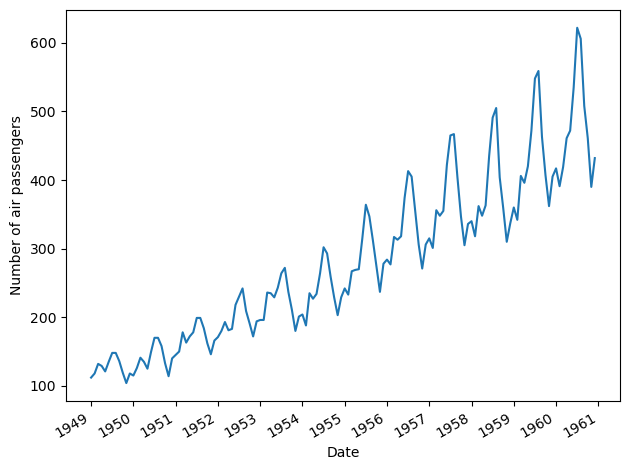

In [32]:
fig, ax = plt.subplots()

ax.plot(df["Month"], df["Passengers"])

ax.set_xlabel("Date")
ax.set_ylabel("Number of air passengers")

plt.xticks(np.arange(0, 145, 12), np.arange(1949, 1962, 1))

fig.autofmt_xdate()
plt.tight_layout()

plt.show()

- 뚜렷한 계절적 패턴이 보임
    - 연초와 연말에 낮고 매년 중반에 최대 유동량 발생

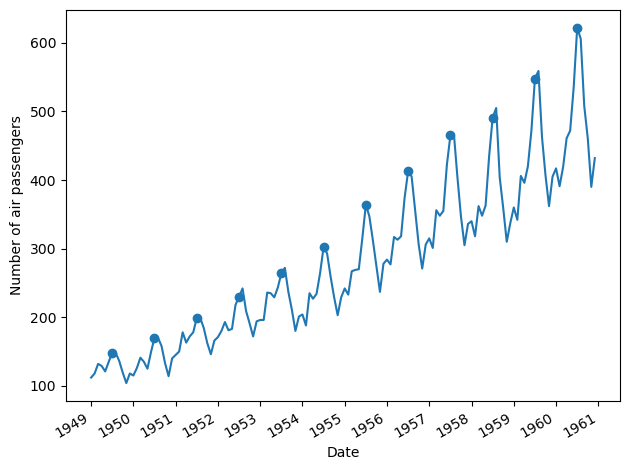

In [33]:
# 매년 7월에 marker 표시
fig, ax = plt.subplots()

ax.plot(df["Month"], df["Passengers"], markevery = np.arange(6, 145, 12), marker = "o")

ax.set_xlabel("Date")
ax.set_ylabel("Number of air passengers")

plt.xticks(np.arange(0, 145, 12), np.arange(1949, 1962, 1))

fig.autofmt_xdate()
plt.tight_layout()

plt.show()

- 이 데이터는 월별 데이터이므로 m = 12
    - 따라서 1961년 7월을 예측한다면 이전 해의 7월 정보를 유용하게 사용할 수 있을 것
 
- 매개변수 P, D, Q, m을 사용하면 이전 계절 주기로부터 해당 정보를 포착하여 시계열 예측 수행 가능

# 시계열에서 계절적 패턴 식별

- 계절적 패턴을 보이는 데이터에 SARIMA 모델을 적용하는 것이 합리적이므로 시계열에서 계절성을 식별하는 방법을 선택하는 것이 중요

1. 시계열 데이터 시각화
    - 일반적으로 시계열 데이터를 시각화하는 것만으로도 주기적인 패턴 관찰 가능

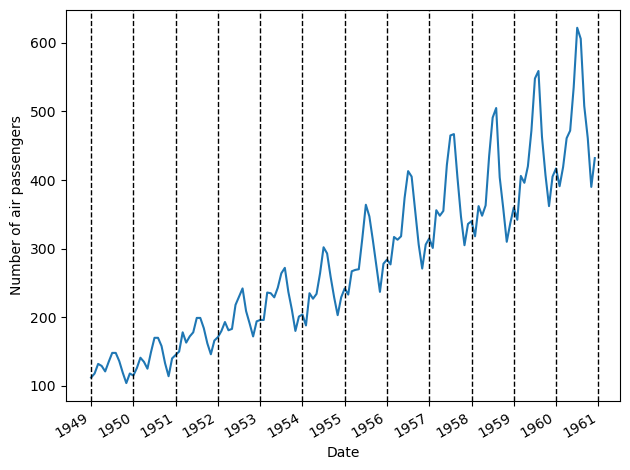

In [34]:
fig, ax = plt.subplots()

ax.plot(df["Month"], df["Passengers"])

ax.set_xlabel("Date")
ax.set_ylabel("Number of air passengers")
# ax.grid(axis = "x")
for i in np.arange(0, 145, 12):
    ax.axvline(x = i, linestyle = "--", color = "black", linewidth = 1)

plt.xticks(np.arange(0, 145, 12), np.arange(1949, 1962, 1))

fig.autofmt_xdate()
plt.tight_layout()

plt.show()

- 매년 중반에 피크가 발생하며 매년 초와 말에 유사한 패턴이 나타남

2. 시계열 분해
    - 시계열을 추세, 계절적 구성 요소, 잔차의 세 가지 주요 구성 요소로 분리하는 통계 작업

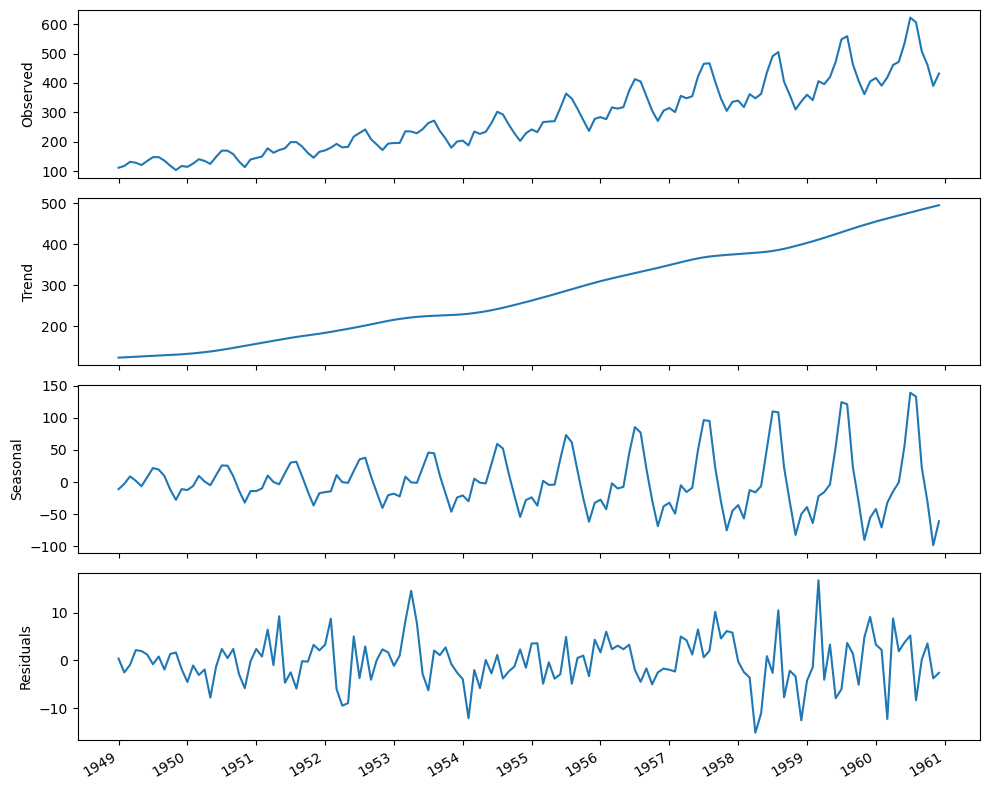

In [35]:
decomposition = STL(df["Passengers"], period = 12).fit()

fit, (ax1, ax2, ax3, ax4) = plt.subplots(nrows = 4, ncols = 1, sharex = True, figsize = (10, 8))

ax1.plot(decomposition.observed)
ax1.set_ylabel("Observed")

ax2.plot(decomposition.trend)
ax2.set_ylabel("Trend")

ax3.plot(decomposition.seasonal)
ax3.set_ylabel("Seasonal")

ax4.plot(decomposition.resid)
ax4.set_ylabel("Residuals")

plt.xticks(np.arange(0, 145, 12), np.arange(1949, 1962, 1))

fit.autofmt_xdate()
plt.tight_layout()

plt.show()

- 추세 : 시간이 지남에 따라 항공 승객 수가 증가하고 있음

- 계절적 구성 요소 : 반복되는 패턴을 명확하게 볼 수 있음

- 추세, 계절, 잔차, 구성 요소의 합은 맨 위 도식에 표시된 관측 데이터가 됨

## 계절적 패턴이 없는 시계열 분해 예제

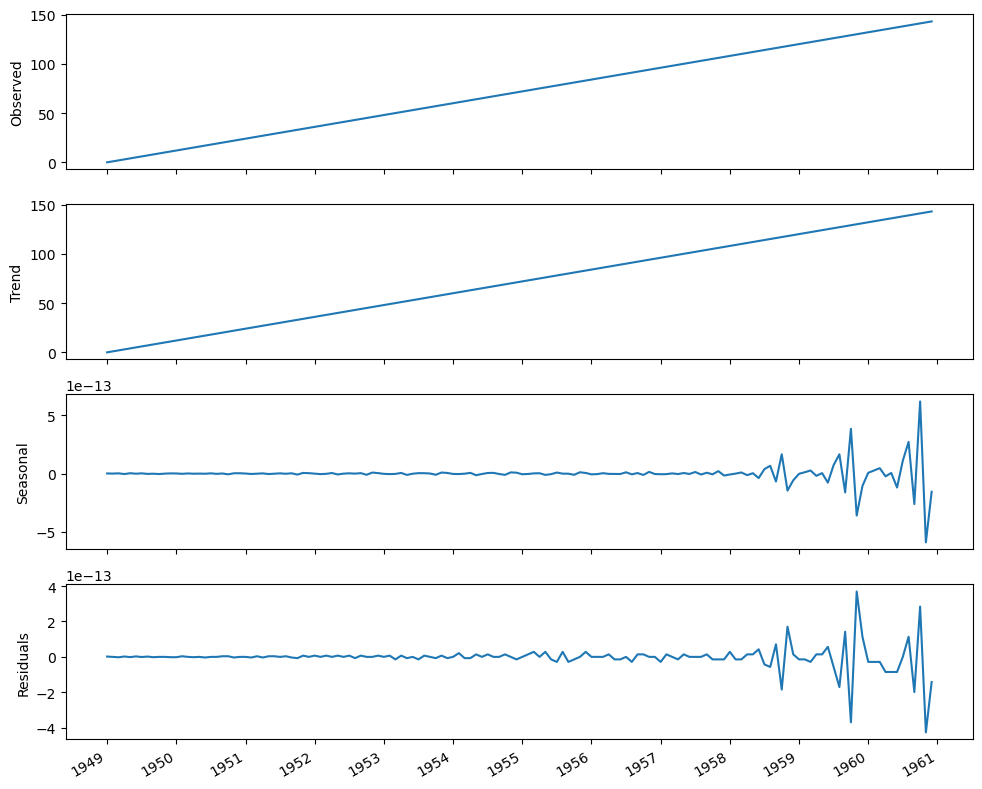

In [36]:
linear_ts = np.arange(0, 144, 1)

decomposition = STL(linear_ts, period = 12).fit()

fit, (ax1, ax2, ax3, ax4) = plt.subplots(nrows = 4, ncols = 1, sharex = True, figsize = (10, 8))

ax1.plot(decomposition.observed)
ax1.set_ylabel("Observed")

ax2.plot(decomposition.trend)
ax2.set_ylabel("Trend")

ax3.plot(decomposition.seasonal)
ax3.set_ylabel("Seasonal")

ax4.plot(decomposition.resid)
ax4.set_ylabel("Residuals")

plt.xticks(np.arange(0, 145, 12), np.arange(1949, 1962, 1))

fit.autofmt_xdate()
plt.tight_layout()

plt.show()

- 1번과 2번 모두 통계적 테스트가 아닌 시각적 방법이지만, 시계열의 계절성 여부를 판단하기에 충분

- 시계열에서 계절성을 식별하는 통계적 테스트는 없음

# 월간 항공 승객 수 예측

- 일반적 모델링 절차에 SARIMA 모델의 새로운 매개변수를 고려할 수 있도록 절차 수정

<img src = "./image/sarima모델링_절차.png" width = 600, height = 600>

## ARIMA(p, d, q) 모델을 사용하여 예측

- 1년간의 월별 항공 승객 수를 테스트 집합으로 사용

- 베이스라인 모델
    - 단순 계절적 예측
 
- 계절적 요소를 추가하면 더 나은 예측을 얻을 수 있는 지 검증하기 위해 ARIMA(p, d, q)와 SARIMA(p, d, q)(P, D, Q)m 모델을 모두 사용

In [37]:
# 일반적 모델링 절차에 따라 정상성 테스트
ad_fuller_result = adfuller(df["Passengers"])

print(f"ADF Statistic: {ad_fuller_result[0]}")
print(f"p-value: {ad_fuller_result[1]}")

ADF Statistic: 0.8153688792060472
p-value: 0.991880243437641


- 귀무가설을 기각할 수 없으며 비정상 수열

In [38]:
# 1차 사분
df_diff = np.diff(df["Passengers"], n = 1)

ad_fuller_result = adfuller(df["Passengers"])

print(f"ADF Statistic: {ad_fuller_result[0]}")
print(f"p-value: {ad_fuller_result[1]}")

ADF Statistic: 0.8153688792060472
p-value: 0.991880243437641


- p-value가 0.054이므로 귀무가설을 기각할 수 없으며 비정상 수열임

In [39]:
# 2차 차분
df_diff2 = np.diff(df_diff, n = 1)

ad_fuller_result = adfuller(df_diff2)

print(f"ADF Statistic: {ad_fuller_result[0]}")
print(f"p-value: {ad_fuller_result[1]}")

ADF Statistic: -16.384231542468463
p-value: 2.732891850014476e-29


- 귀무가설을 기각할 수 있으며, 정상 시계열로 간주 가능

- 두 번 차분되어 정상성을 만족하게 되었으므로 d = 2

- 매개변수 p, q에 가능한 값의 범위를 정의하고 모든 고유한 ARIMA(p, d, q) 모델을 훈련

- 0에서 12 사이의 범위를 선택하여 ARIMA 모델이 12 timestep을 거슬러 올라가도록 설정
    - 데이터가 매월 측정되고 계절적 요인이 있다는 것을 알고 있으므로 ARIMA 모델이 계절 정보를 잠재적으로 포착할 수 있는 지 알아보기 위함

In [40]:
ps = range(0, 13, 1)
qs = range(0, 13, 1)
Ps = [0] # 현재는 ARIMA 모델을 작업 중이므로 P와 Q를 0으로 설정
Qs = [0]

d = 2 # 차분 횟수
D = 0 # ARIMA 모델을 작업 중이므로 D = 0
s = 12 # 매개변수 m, statsmodels 라이브러리에서는 m을 s로 표현

ARIMA_order_list = list(product(ps, qs, Ps, Qs))

In [41]:
ARIMA_order_list

[(0, 0, 0, 0),
 (0, 1, 0, 0),
 (0, 2, 0, 0),
 (0, 3, 0, 0),
 (0, 4, 0, 0),
 (0, 5, 0, 0),
 (0, 6, 0, 0),
 (0, 7, 0, 0),
 (0, 8, 0, 0),
 (0, 9, 0, 0),
 (0, 10, 0, 0),
 (0, 11, 0, 0),
 (0, 12, 0, 0),
 (1, 0, 0, 0),
 (1, 1, 0, 0),
 (1, 2, 0, 0),
 (1, 3, 0, 0),
 (1, 4, 0, 0),
 (1, 5, 0, 0),
 (1, 6, 0, 0),
 (1, 7, 0, 0),
 (1, 8, 0, 0),
 (1, 9, 0, 0),
 (1, 10, 0, 0),
 (1, 11, 0, 0),
 (1, 12, 0, 0),
 (2, 0, 0, 0),
 (2, 1, 0, 0),
 (2, 2, 0, 0),
 (2, 3, 0, 0),
 (2, 4, 0, 0),
 (2, 5, 0, 0),
 (2, 6, 0, 0),
 (2, 7, 0, 0),
 (2, 8, 0, 0),
 (2, 9, 0, 0),
 (2, 10, 0, 0),
 (2, 11, 0, 0),
 (2, 12, 0, 0),
 (3, 0, 0, 0),
 (3, 1, 0, 0),
 (3, 2, 0, 0),
 (3, 3, 0, 0),
 (3, 4, 0, 0),
 (3, 5, 0, 0),
 (3, 6, 0, 0),
 (3, 7, 0, 0),
 (3, 8, 0, 0),
 (3, 9, 0, 0),
 (3, 10, 0, 0),
 (3, 11, 0, 0),
 (3, 12, 0, 0),
 (4, 0, 0, 0),
 (4, 1, 0, 0),
 (4, 2, 0, 0),
 (4, 3, 0, 0),
 (4, 4, 0, 0),
 (4, 5, 0, 0),
 (4, 6, 0, 0),
 (4, 7, 0, 0),
 (4, 8, 0, 0),
 (4, 9, 0, 0),
 (4, 10, 0, 0),
 (4, 11, 0, 0),
 (4, 12, 0, 0),
 (5, 0, 0,

In [42]:
def optimize_SARIMA(endog: Union[pd.Series, list], order_list: list, d: int, D: int, s: int) -> pd.DataFrame:
    '''
    endog : 예측하고자 하는 대상 시계열 데이터
    order_list : p, q 조합 리스트
    d : 적분 차수
    D : 계절적 적분 차수
    s : 빈도
    '''
    results = [] # 차수 p, q와 그에 해당하는 AIC를 저장할 리스트

    for order in tqdm_notebook(order_list):
        try:
            model = SARIMAX(
                endog,
                order = (order[0], d, order[1]),
                seasonal_order = (order[2], D, order[3], s)).fit(disp = False)

        except:
            continue

        aic = model.aic # 모델의 AIC를 계산
        results.append([order, aic]) # 결과 리스트에 p, q 조합과 AIC를 추가

    result_df = pd.DataFrame(results)
    result_df.columns = ["(p, q, P, Q)", "AIC"]

    # 오름차순 정렬, AIC가 낮을수록 좋음
    result_df = result_df.sort_values(by = "AIC", ascending = True).reset_index(drop = True)

    return result_df

In [43]:
# optimize_SARIMA 함수를 사용하지만 P, D, Q를 0으로 설정했기 때문에 ARIMA 모델 훈련
train = df["Passengers"][:-12] # 마지막 연도 데이터 제외 전부

ARIMA_result_df = optimize_SARIMA(train, ARIMA_order_list, d, D, s)
ARIMA_result_df

  0%|          | 0/169 [00:00<?, ?it/s]

,"(p, q, P, Q)",AIC
0,"(11, 3, 0, 0)",1016.876132
1,"(11, 4, 0, 0)",1019.012823
2,"(11, 5, 0, 0)",1020.427116
3,"(12, 0, 0, 0)",1020.624874
4,"(11, 1, 0, 0)",1021.020774
...,...,...
164,"(5, 0, 0, 0)",1281.732157
165,"(3, 0, 0, 0)",1300.282335
166,"(2, 0, 0, 0)",1302.913196
167,"(1, 0, 0, 0)",1308.152194


- AIC가 가장 낮은 모델은 SARIMA(11, 2, 3)(0, 0, 0)12 모델이고 이는 ARIMA(11, 2, 3)과 동일
    - p = 11이므로 차수를 다양하게 적용해본 것이 모델에 유리했음을 확인

In [44]:
# 잔차분석
ARIMA_model = SARIMAX(train, order = (11, 2, 3))
ARIMA_model_fit = ARIMA_model.fit(disp = False)

print(ARIMA_model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:             Passengers   No. Observations:                  132
Model:              SARIMAX(11, 2, 3)   Log Likelihood                -493.438
Date:                Mon, 20 Jul 2026   AIC                           1016.876
Time:                        11:48:08   BIC                           1059.889
Sample:                             0   HQIC                          1034.354
                                - 132                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8244      0.100     -8.220      0.000      -1.021      -0.628
ar.L2         -0.9615      0.049    -19.571      0.000      -1.058      -0.865
ar.L3         -0.8508      0.088     -9.723      0.0

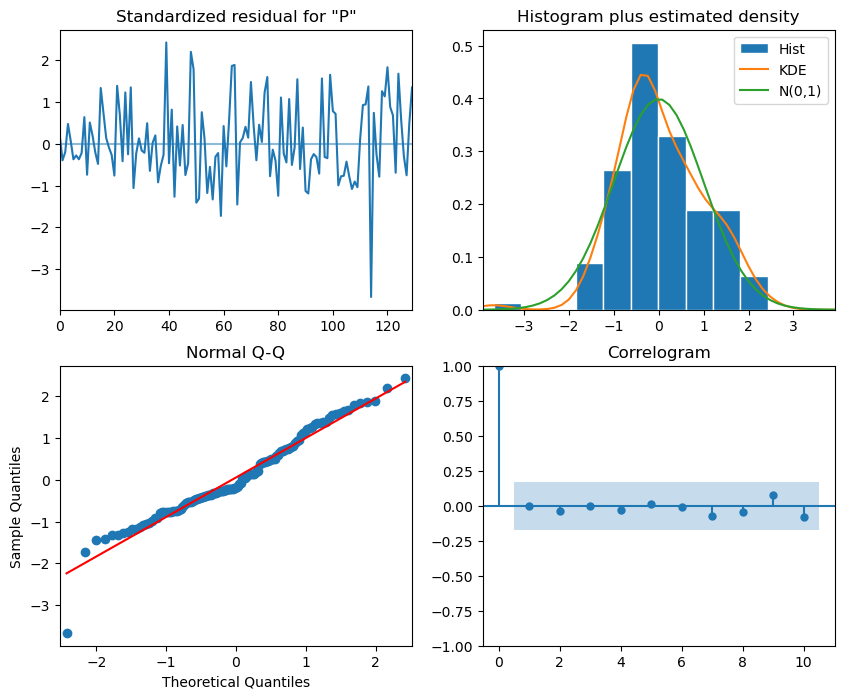

In [45]:
ARIMA_model_fit.plot_diagnostics(figsize = (10, 8))

plt.show()

- 잔차가 시간이 지남에 따라 분산이 일정하고 주체가 없어 백색소음과 유사

- 비정상적인 피크를 가지고 있지만 그 외에는 정규분포에 가까운 분포

- Q-Q plot에서는 직선에 가까움

- 자기상관관계가 없어 백색소음과 유사

In [46]:
# 융-박스 테스트
residuals = ARIMA_model_fit.resid

rt = acorr_ljungbox(residuals, np.arange(1, 11, 1))

print(rt)

      lb_stat  lb_pvalue
1    6.532249   0.010594
2    6.640276   0.036148
3    6.902114   0.075084
4    7.722050   0.102307
5    8.359122   0.137523
6    8.668036   0.193126
7    9.526203   0.217050
8    9.754443   0.282686
9    9.763811   0.369942
10  11.534901   0.317388


- 처음 두 값을 제외하고 모두 0.05보다 큼
    - 지연 3부터는 상관관계가 없음
 
- 시각적 분석으로는 백색소음과 비슷하다는 결론을 내릴 수 있지만, 융-박스 테스트에서는 지연1과 지연2에서 상관관계가 있다는 것을 확인 가능
    - 따라서 모델이 완벽하게 데이터를 모델링하고 있지 않음
    - 이번 예제에서는 비계절적 모델로 계절적 데이터를 모델링하고 있다는 것을 알고 있으며, 비교를 위해 계속 진행

In [47]:
test = df.iloc[-12:]

In [48]:
test["naive_seasonal"] = df["Passengers"].iloc[120:132].values
test

,Month,Passengers,naive_seasonal
132,1960-01,417,360
133,1960-02,391,342
134,1960-03,419,406
135,1960-04,461,396
136,1960-05,472,420
137,1960-06,535,472
138,1960-07,622,548
139,1960-08,606,559
140,1960-09,508,463
141,1960-10,461,407


In [50]:
ARIMA_pred = ARIMA_model_fit.get_prediction(132, 143).predicted_mean

In [51]:
test["ARIMA_pred"] = ARIMA_pred
test

,Month,Passengers,naive_seasonal,ARIMA_pred
132,1960-01,417,360,422.189878
133,1960-02,391,342,410.548836
134,1960-03,419,406,461.599222
135,1960-04,461,396,457.401337
136,1960-05,472,420,481.450278
137,1960-06,535,472,530.729753
138,1960-07,622,548,606.040377
139,1960-08,606,559,615.352591
140,1960-09,508,463,525.702716
141,1960-10,461,407,467.434450


## SARIMA(p, d, q)(P, D, Q)m 모델 사용하여 예측

- SARIMA 모델이 ARIMA 모델보다 더 나은 성능을 보이는 지 확인

In [52]:
ad_fuller_result = adfuller(df["Passengers"])

print(f"ADF Statistic: {ad_fuller_result[0]}")
print(f"p-value: {ad_fuller_result[1]}")

ADF Statistic: 0.8153688792060472
p-value: 0.991880243437641


In [53]:
df_diff = np.diff(df["Passengers"], n = 1)

ad_fuller_result = adfuller(df_diff)

print(f"ADF Statistic: {ad_fuller_result[0]}")
print(f"p-value: {ad_fuller_result[1]}")

ADF Statistic: -2.8292668241699905
p-value: 0.05421329028382671


- 계절적 차분
    - 계절성이 있는 시계열은 두 종류의 비정상성이 있을 수 있음
        - 추세
        - 계절성
 
    - 1차 차분은 추세를 제거하지만 계절 패턴까지는 제거하지 못함
 
    - 1차 차분 이후에도 비정상 시계열이라면 추세가 남아가 아니라 계절성이 남아있기 때문일 가능성이 있음

In [55]:
# 계절적 차분
df_diff_seasonal_diff = df_diff[12:] - df_diff[:-12]

ad_fuller_result = adfuller(df_diff_seasonal_diff)

print(f"ADF Statistic: {ad_fuller_result[0]}")
print(f"p-value: {ad_fuller_result[1]}")

ADF Statistic: -15.595618083746338
p-value: 1.856511600123444e-28


- 한 번의 차분과 한 번의 계절적 차분으로 정상 시계열로 변환
    - d = 1, D = 1

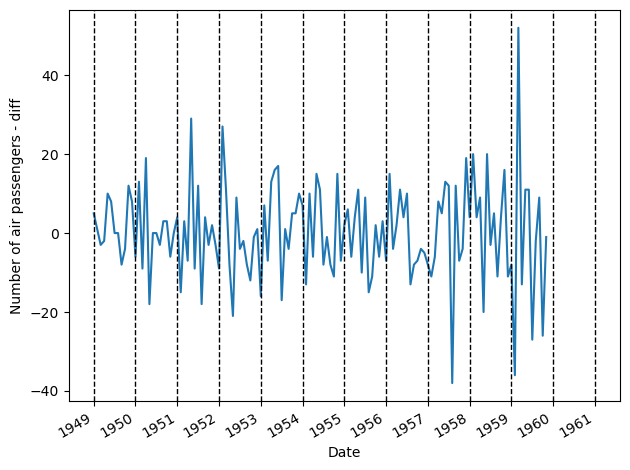

In [56]:
fig, ax = plt.subplots()

ax.plot(df["Month"][13:], df_diff_seasonal_diff)

ax.set_xlabel("Date")
ax.set_ylabel("Number of air passengers - diff")
# ax.grid(axis = "x")
for i in np.arange(0, 145, 12):
    ax.axvline(x = i, linestyle = "--", color = "black", linewidth = 1)

plt.xticks(np.arange(0, 145, 12), np.arange(1949, 1962, 1))

fig.autofmt_xdate()
plt.tight_layout()

plt.show()

In [58]:
# p, q, P, Q 값의 범위 정의
ps = range(0, 3, 1)
qs = range(0, 3, 1)
Ps = range(0, 3, 1)
Qs = range(0, 3, 1)

SARIMA_order_list = list(product(ps, qs, Ps, Qs))
SARIMA_order_list

[(0, 0, 0, 0),
 (0, 0, 0, 1),
 (0, 0, 0, 2),
 (0, 0, 1, 0),
 (0, 0, 1, 1),
 (0, 0, 1, 2),
 (0, 0, 2, 0),
 (0, 0, 2, 1),
 (0, 0, 2, 2),
 (0, 1, 0, 0),
 (0, 1, 0, 1),
 (0, 1, 0, 2),
 (0, 1, 1, 0),
 (0, 1, 1, 1),
 (0, 1, 1, 2),
 (0, 1, 2, 0),
 (0, 1, 2, 1),
 (0, 1, 2, 2),
 (0, 2, 0, 0),
 (0, 2, 0, 1),
 (0, 2, 0, 2),
 (0, 2, 1, 0),
 (0, 2, 1, 1),
 (0, 2, 1, 2),
 (0, 2, 2, 0),
 (0, 2, 2, 1),
 (0, 2, 2, 2),
 (1, 0, 0, 0),
 (1, 0, 0, 1),
 (1, 0, 0, 2),
 (1, 0, 1, 0),
 (1, 0, 1, 1),
 (1, 0, 1, 2),
 (1, 0, 2, 0),
 (1, 0, 2, 1),
 (1, 0, 2, 2),
 (1, 1, 0, 0),
 (1, 1, 0, 1),
 (1, 1, 0, 2),
 (1, 1, 1, 0),
 (1, 1, 1, 1),
 (1, 1, 1, 2),
 (1, 1, 2, 0),
 (1, 1, 2, 1),
 (1, 1, 2, 2),
 (1, 2, 0, 0),
 (1, 2, 0, 1),
 (1, 2, 0, 2),
 (1, 2, 1, 0),
 (1, 2, 1, 1),
 (1, 2, 1, 2),
 (1, 2, 2, 0),
 (1, 2, 2, 1),
 (1, 2, 2, 2),
 (2, 0, 0, 0),
 (2, 0, 0, 1),
 (2, 0, 0, 2),
 (2, 0, 1, 0),
 (2, 0, 1, 1),
 (2, 0, 1, 2),
 (2, 0, 2, 0),
 (2, 0, 2, 1),
 (2, 0, 2, 2),
 (2, 1, 0, 0),
 (2, 1, 0, 1),
 (2, 1, 0, 2),
 (2, 1, 1,

In [59]:
d = 1
D = 1
s = 12

In [60]:
SARIMA_result_df = optimize_SARIMA(train, SARIMA_order_list, d, D, s)
SARIMA_result_df

  0%|          | 0/81 [00:00<?, ?it/s]

,"(p, q, P, Q)",AIC
0,"(2, 1, 1, 2)",892.248024
1,"(2, 1, 2, 1)",893.809440
2,"(1, 0, 1, 2)",894.283302
3,"(0, 1, 1, 2)",894.995202
4,"(1, 0, 2, 1)",895.091048
...,...,...
76,"(0, 0, 1, 0)",905.225875
77,"(0, 0, 0, 1)",905.418880
78,"(0, 0, 1, 1)",906.058298
79,"(0, 0, 0, 2)",906.888588


In [61]:
SARIMA_model = SARIMAX(train, order = (2, 1, 1), seasonal_order = (1, 1, 2, 12))
SARIMA_model_fit = SARIMA_model.fit(disp = False)

print(SARIMA_model_fit.summary())

                                        SARIMAX Results                                        
Dep. Variable:                              Passengers   No. Observations:                  132
Model:             SARIMAX(2, 1, 1)x(1, 1, [1, 2], 12)   Log Likelihood                -439.124
Date:                                 Mon, 20 Jul 2026   AIC                            892.248
Time:                                         12:27:39   BIC                            911.702
Sample:                                              0   HQIC                           900.148
                                                 - 132                                         
Covariance Type:                                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.2676      0.085    -14.997      0.000      -1.433      -1

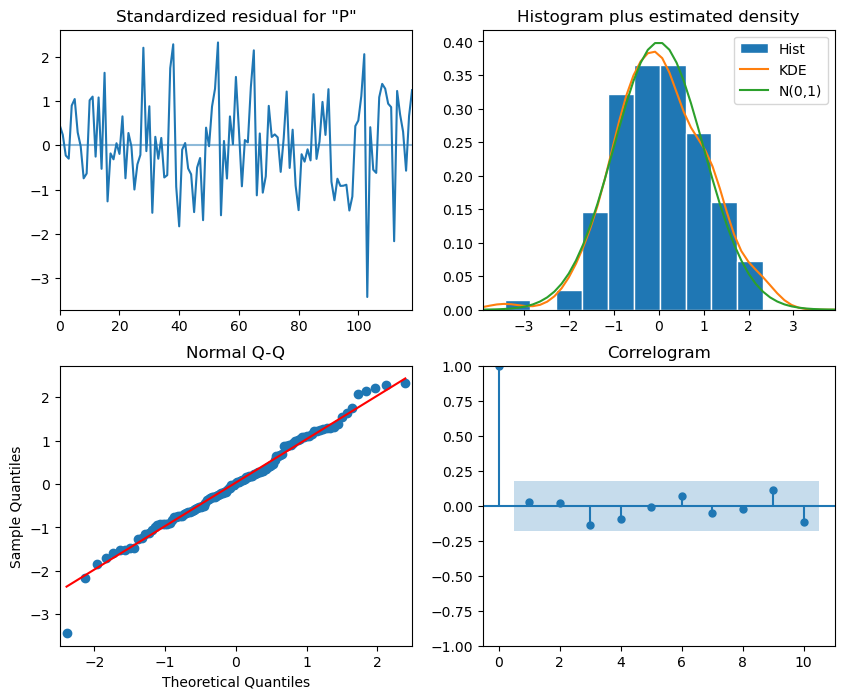

In [62]:
SARIMA_model_fit.plot_diagnostics(figsize = (10, 8))

plt.show()

- 잔차가 추세나 분산 변화를 나타내지 않음

- 히스토그램과 Q-Q plot으로는 정규분포에 매우 가까워 보임

- 상관관계 그래프에서는 지연 0 이후 유의한 계수가 없음

- 따라서 잔차가 백색소음과 유사

In [63]:
residuals = SARIMA_model_fit.resid

rt = acorr_ljungbox(residuals, np.arange(1, 11, 1))

print(rt)

     lb_stat  lb_pvalue
1   0.005226   0.942369
2   0.740560   0.690541
3   1.013346   0.798023
4   1.219196   0.874928
5   1.432717   0.920701
6   1.706066   0.944652
7   2.299330   0.941435
8   2.707213   0.951368
9   2.722441   0.974291
10  4.956604   0.894058


- 모든 p-value가 0.05보다 큼
    - 귀무가설을 기각하지 않고 잔차가 백색소음과 마찬가지로 독립적이고 상관관계가 없음

In [64]:
# 1960년 한 해 동안의 월별 항공 승객 수 예측
SARIMA_pred = SARIMA_model_fit.get_prediction(132, 143).predicted_mean

In [65]:
test["SARIMA_pred"] = SARIMA_pred
test

,Month,Passengers,naive_seasonal,ARIMA_pred,SARIMA_pred
132,1960-01,417,360,422.189878,418.548049
133,1960-02,391,342,410.548836,399.618236
134,1960-03,419,406,461.599222,461.375929
135,1960-04,461,396,457.401337,451.501347
136,1960-05,472,420,481.450278,473.833999
137,1960-06,535,472,530.729753,538.823645
138,1960-07,622,548,606.040377,612.551429
139,1960-08,606,559,615.352591,624.761066
140,1960-09,508,463,525.702716,520.255369
141,1960-10,461,407,467.434450,462.932395


## 각 예측 방법 성능 비교

- 단순 계절 예측, ARIMA 모델, SARIMA 모델 성능 비교

- 평가 지표는 MAPE(평균절대백분율오차) 사용

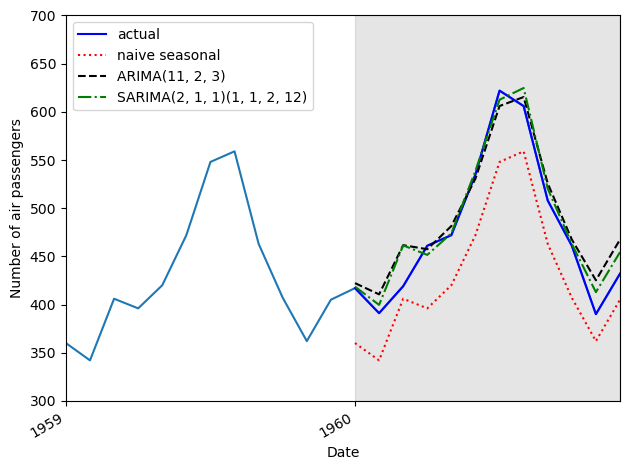

In [66]:
fig, ax = plt.subplots()

ax.plot(df["Month"], df["Passengers"])
ax.plot(test["Passengers"], "b-", label = "actual")
ax.plot(test["naive_seasonal"], "r:", label = "naive seasonal")
ax.plot(test["ARIMA_pred"], "k--", label = "ARIMA(11, 2, 3)")
ax.plot(test["SARIMA_pred"], "g-.", label = "SARIMA(2, 1, 1)(1, 1, 2, 12)")

ax.set_xlabel("Date")
ax.set_ylabel("Number of air passengers")
ax.axvspan(132, 143, color = "#808080", alpha = 0.2)
ax.legend()

plt.xticks(np.arange(0, 145, 12), np.arange(1949, 1962, 1))
ax.set_xlim(120, 143)
ax.set_ylim(300, 700)

fig.autofmt_xdate()
plt.tight_layout()

plt.show()

- ARIMA 및 SARIMA 모델의 선은 관측 데이터에 매우 가까움

In [67]:
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [68]:
mape_naive_seasonal = mape(test["Passengers"], test["naive_seasonal"])
mape_ARIMA = mape(test["Passengers"], test["ARIMA_pred"])
mape_SARIMA = mape(test["Passengers"], test["SARIMA_pred"])

print(mape_naive_seasonal, mape_ARIMA, mape_SARIMA)

9.987532920823485 3.8492175515691534 2.860151768099456


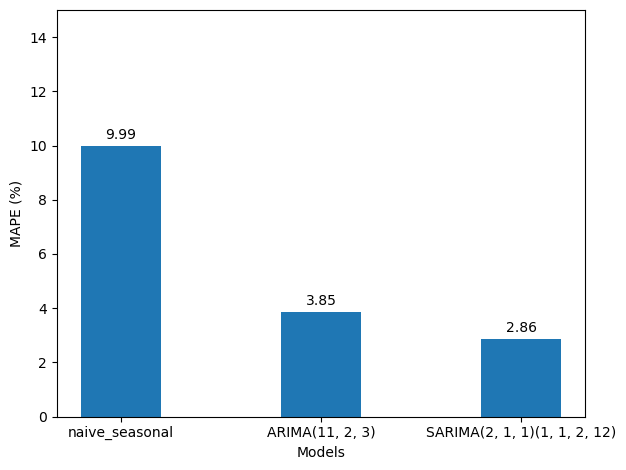

In [69]:
fig, ax = plt.subplots()

x = ["naive_seasonal", "ARIMA(11, 2, 3)", "SARIMA(2, 1, 1)(1, 1, 2, 12)"]
y = [mape_naive_seasonal, mape_ARIMA, mape_SARIMA]

ax.bar(x, y, width = 0.4)
ax.set_xlabel("Models")
ax.set_ylabel("MAPE (%)")
ax.set_ylim(0, 15)

for index, value in enumerate(y):
    plt.text(x = index, y = value + 0.25, s = str(round(value, 2)), ha = "center")

plt.tight_layout()
plt.show()

- 예측하려는 데이터의 계절성이 명확하고 SARIMA 모델이 시계열의 계절적 속성을 사용하여 예측하도록 구축되었기 때문에 SARIMA 모델의 성능이 가장 좋은 방법이 됨

# 정리

- 계절적 자기회귀누적이동평균 모델은 SARIMA(p, d, q)(P, D, Q)m으로 표시되며, ARIMA(p, d, q) 모델에 계절적 속성을 추가한 것

- P는 계절적 자기회귀과정의 차수, D는 계절적 적분 과정의 차수, Q는 계절적 이동평균과정의 차수, m은 데이터의 빈도